In [3]:
import os
import pandas as pd
from datetime import datetime

In [7]:
HISTORY_FILE = "history.csv"

In [8]:
if os.path.exists(HISTORY_FILE):
    history_df = pd.read_csv(HISTORY_FILE)
else:
    history_df = pd.DataFrame(columns=["Date","Defect","Area","Efficiency"])

Loading models...
Efficiency model loaded

Processing: data/Solar panel Image/Electrical-damage/Electrical (12).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step

Prediction Probabilities:
Bird-drop: 0.0413
Clean: 0.0528
Dusty: 0.0462
Electrical-damage: 0.8154
Physical-Damage: 0.0393
Snow-Covered: 0.0049


C:\Users\ASus\OneDrive\Desktop\jbooks\venv\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer_6']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


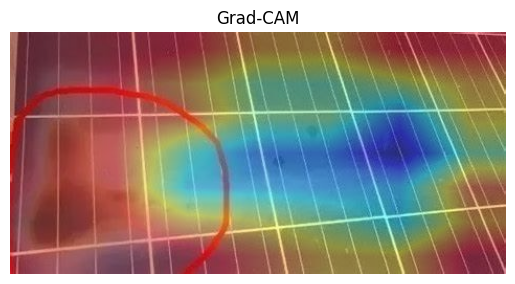


===== SOLAR PANEL REPORT =====

Defect Type: Electrical-damage
Severity Level: High
Defect Area (%): 40.82

--- Analysis ---
Electrical faults reduce efficiency.

--- Efficiency ---
Formula: 24.09%
ML: 59.65420000000004
Final: 41.87%

First run — no history available


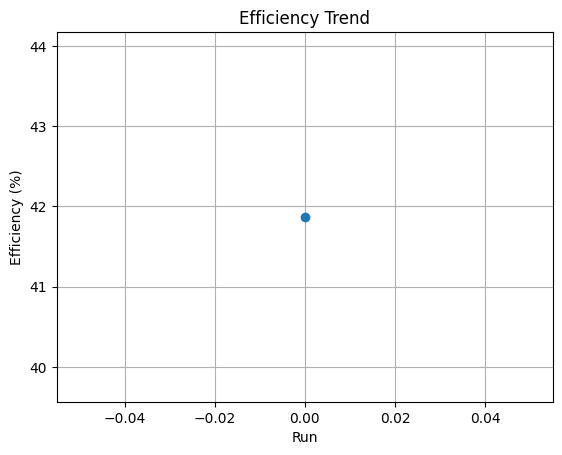

In [9]:
# =========================
# FINAL SOLAR PANEL SYSTEM (WITH HISTORY + GRAPH)
# =========================

import numpy as np
import tensorflow as tf
import cv2
from tensorflow.keras.preprocessing import image
import joblib
import os
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# =========================
# CONFIG
# =========================
IMG_PATH = "data/Solar panel Image/Electrical-damage/Electrical (12).jpg"
HISTORY_FILE = "history.csv"
SHOW_HEATMAP = True

# =========================
# LOAD MODELS
# =========================
print("Loading models...")

image_model = tf.keras.models.load_model("best_model.keras")

eff_model = None
if os.path.exists("efficiency_model.pkl"):
    eff_model = joblib.load("efficiency_model.pkl")
    print("Efficiency model loaded")
else:
    print("⚠️ No efficiency model found")

# =========================
# CLASS + MAPS
# =========================
classes = [
    "Bird-drop","Clean","Dusty",
    "Electrical-damage","Physical-Damage","Snow-Covered"
]

loss_map = {
    "Clean": 0.0,
    "Dusty": 0.15,
    "Bird-drop": 0.20,
    "Electrical-damage": 0.40,
    "Physical-Damage": 0.50,
    "Snow-Covered": 0.30
}

explanation_map = {
    "Clean": "No defect detected. Panel operating normally.",
    "Dusty": "Dust reduces sunlight absorption.",
    "Bird-drop": "Bird droppings block panel surface.",
    "Electrical-damage": "Electrical faults reduce efficiency.",
    "Physical-Damage": "Structural damage affects output.",
    "Snow-Covered": "Snow blocks sunlight completely."
}

# =========================
# INPUTS (CHANGE IF NEEDED)
# =========================
temperature = 30
irradiance = 900
humidity = 60
wind_speed = 5

# =========================
# LOAD HISTORY
# =========================
if os.path.exists(HISTORY_FILE):
    history_df = pd.read_csv(HISTORY_FILE)
else:
    history_df = pd.DataFrame(columns=["Date","Defect","Area","Efficiency"])

# =========================
# GRAD-CAM
# =========================
def get_defect_area(img_path):

    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)/255
    img_array = np.expand_dims(img_array, axis=0)

    grad_model = tf.keras.models.Model(
        [image_model.inputs],
        [image_model.get_layer("conv5_block3_out").output, image_model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(img_array)
        class_idx = np.argmax(preds[0])
        loss = preds[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap).numpy()

    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap) + 1e-8

    threshold = np.mean(heatmap)
    mask = heatmap > threshold
    area = np.sum(mask) / mask.size

    # 🔥 Heatmap overlay
    if SHOW_HEATMAP:
        original = cv2.imread(img_path)
        original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

        heatmap_resized = cv2.resize(heatmap, (original.shape[1], original.shape[0]))
        heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)

        overlay = cv2.addWeighted(original, 0.6, heatmap_color, 0.4, 0)

        plt.imshow(overlay)
        plt.title("Grad-CAM")
        plt.axis('off')
        plt.show()

    return area * 100

# =========================
# MAIN SYSTEM
# =========================
def run_system(img_path):

    print("\nProcessing:", img_path)

    # IMAGE
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)/255
    img_array = np.expand_dims(img_array, axis=0)

    pred = image_model.predict(img_array)

    print("\nPrediction Probabilities:")
    for i, cls in enumerate(classes):
        print(f"{cls}: {pred[0][i]:.4f}")

    defect = classes[np.argmax(pred)]

    # AREA
    area = get_defect_area(img_path)

    # SEVERITY
    severity = "Low" if area < 10 else "Medium" if area < 30 else "High"

    # LOSSES
    defect_loss = loss_map[defect]
    area_loss = area * 0.005
    temp_loss = max(0, (temperature - 25) * 0.004)
    irr_loss = max(0, (1000 - irradiance)/1000 * 0.1)
    humidity_loss = humidity * 0.002
    wind_loss = wind_speed * 0.001

    total_loss = defect_loss + area_loss + temp_loss + irr_loss + humidity_loss + wind_loss

    formula_eff = max(0, min(100 * (1 - total_loss), 100))

    # ML
    if eff_model:
        features = pd.DataFrame([{
            "defect_loss": defect_loss,
            "defect_area": area,
            "temperature": temperature,
            "irradiance": irradiance,
            "humidity": humidity,
            "wind_speed": wind_speed
        }])

        ml_eff = max(0, min(eff_model.predict(features)[0], 100))
        final_eff = (formula_eff + ml_eff) / 2
    else:
        ml_eff = "N/A"
        final_eff = formula_eff

    # =========================
    # HISTORY COMPARISON
    # =========================
    if len(history_df) > 0:
        prev_eff = history_df.iloc[-1]["Efficiency"]
        drop = prev_eff - final_eff
    else:
        prev_eff = None
        drop = None

    # =========================
    # SAVE HISTORY
    # =========================
    new_row = {
        "Date": datetime.now().strftime("%Y-%m-%d %H:%M"),
        "Defect": defect,
        "Area": round(area,2),
        "Efficiency": round(final_eff,2)
    }

    history_df.loc[len(history_df)] = new_row
    history_df.to_csv(HISTORY_FILE, index=False)

    # =========================
    # OUTPUT
    # =========================
    print("\n===== SOLAR PANEL REPORT =====\n")

    print(f"Defect Type: {defect}")
    print(f"Severity Level: {severity}")
    print(f"Defect Area (%): {area:.2f}")

    print("\n--- Analysis ---")
    print(explanation_map[defect])

    print("\n--- Efficiency ---")
    print(f"Formula: {formula_eff:.2f}%")
    print(f"ML: {ml_eff}")
    print(f"Final: {final_eff:.2f}%")

    if prev_eff is not None:
        print("\n--- Comparison ---")
        print(f"Previous Efficiency: {prev_eff:.2f}%")
        print(f"Drop: {drop:.2f}%")
    else:
        print("\nFirst run — no history available")

    # =========================
    # GRAPH
    # =========================
    plt.figure()
    plt.plot(history_df["Efficiency"], marker='o')
    plt.title("Efficiency Trend")
    plt.xlabel("Run")
    plt.ylabel("Efficiency (%)")
    plt.grid()
    plt.show()

# =========================
# RUN
# =========================
run_system(IMG_PATH)

In [10]:
# =========================
# FINAL SOLAR PANEL SYSTEM (WITH HISTORY + GRAPH)
# =========================

import numpy as np
import tensorflow as tf
import cv2
from tensorflow.keras.preprocessing import image
import joblib
import os
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# =========================
# CONFIG
# =========================
IMG_PATH = "data/Solar panel Image/Dusty/Dust (2).jpg"
HISTORY_FILE = "history.csv"
SHOW_HEATMAP = True

# =========================
# LOAD MODELS
# =========================
print("Loading models...")

image_model = tf.keras.models.load_model("best_model.keras")

eff_model = None
if os.path.exists("efficiency_model.pkl"):
    eff_model = joblib.load("efficiency_model.pkl")
    print("Efficiency model loaded")
else:
    print("⚠️ No efficiency model found")

# =========================
# CLASS + MAPS
# =========================
classes = [
    "Bird-drop","Clean","Dusty",
    "Electrical-damage","Physical-Damage","Snow-Covered"
]

loss_map = {
    "Clean": 0.0,
    "Dusty": 0.15,
    "Bird-drop": 0.20,
    "Electrical-damage": 0.40,
    "Physical-Damage": 0.50,
    "Snow-Covered": 0.30
}

explanation_map = {
    "Clean": "No defect detected. Panel operating normally.",
    "Dusty": "Dust reduces sunlight absorption.",
    "Bird-drop": "Bird droppings block panel surface.",
    "Electrical-damage": "Electrical faults reduce efficiency.",
    "Physical-Damage": "Structural damage affects output.",
    "Snow-Covered": "Snow blocks sunlight completely."
}

# =========================
# INPUTS (CHANGE IF NEEDED)
# =========================
temperature = 30
irradiance = 900
humidity = 60
wind_speed = 5

# =========================
# LOAD HISTORY
# =========================
if os.path.exists(HISTORY_FILE):
    history_df = pd.read_csv(HISTORY_FILE)
else:
    history_df = pd.DataFrame(columns=["Date","Defect","Area","Efficiency"])

# =========================
# GRAD-CAM
# =========================
def get_defect_area(img_path):

    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)/255
    img_array = np.expand_dims(img_array, axis=0)

    grad_model = tf.keras.models.Model(
        [image_model.inputs],
        [image_model.get_layer("conv5_block3_out").output, image_model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(img_array)
        class_idx = np.argmax(preds[0])
        loss = preds[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap).numpy()

    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap) + 1e-8

    threshold = np.mean(heatmap)
    mask = heatmap > threshold
    area = np.sum(mask) / mask.size

    # 🔥 Heatmap overlay
    if SHOW_HEATMAP:
        original = cv2.imread(img_path)
        original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

        heatmap_resized = cv2.resize(heatmap, (original.shape[1], original.shape[0]))
        heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)

        overlay = cv2.addWeighted(original, 0.6, heatmap_color, 0.4, 0)

        plt.imshow(overlay)
        plt.title("Grad-CAM")
        plt.axis('off')
        plt.show()

    return area * 100

# =========================
# MAIN SYSTEM
# =========================
def run_system(img_path):

    print("\nProcessing:", img_path)

    # IMAGE
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)/255
    img_array = np.expand_dims(img_array, axis=0)

    pred = image_model.predict(img_array)

    print("\nPrediction Probabilities:")
    for i, cls in enumerate(classes):
        print(f"{cls}: {pred[0][i]:.4f}")

    defect = classes[np.argmax(pred)]

    # AREA
    area = get_defect_area(img_path)

    # SEVERITY
    severity = "Low" if area < 10 else "Medium" if area < 30 else "High"

    # LOSSES
    defect_loss = loss_map[defect]
    area_loss = area * 0.005
    temp_loss = max(0, (temperature - 25) * 0.004)
    irr_loss = max(0, (1000 - irradiance)/1000 * 0.1)
    humidity_loss = humidity * 0.002
    wind_loss = wind_speed * 0.001

    total_loss = defect_loss + area_loss + temp_loss + irr_loss + humidity_loss + wind_loss

    formula_eff = max(0, min(100 * (1 - total_loss), 100))

    # ML
    if eff_model:
        features = pd.DataFrame([{
            "defect_loss": defect_loss,
            "defect_area": area,
            "temperature": temperature,
            "irradiance": irradiance,
            "humidity": humidity,
            "wind_speed": wind_speed
        }])

        ml_eff = max(0, min(eff_model.predict(features)[0], 100))
        final_eff = (formula_eff + ml_eff) / 2
    else:
        ml_eff = "N/A"
        final_eff = formula_eff

    # =========================
    # HISTORY COMPARISON
    # =========================
    if len(history_df) > 0:
        prev_eff = history_df.iloc[-1]["Efficiency"]
        drop = prev_eff - final_eff
    else:
        prev_eff = None
        drop = None

    # =========================
    # SAVE HISTORY
    # =========================
    new_row = {
        "Date": datetime.now().strftime("%Y-%m-%d %H:%M"),
        "Defect": defect,
        "Area": round(area,2),
        "Efficiency": round(final_eff,2)
    }

    history_df.loc[len(history_df)] = new_row
    history_df.to_csv(HISTORY_FILE, index=False)

    # =========================
    # OUTPUT
    # =========================
    print("\n===== SOLAR PANEL REPORT =====\n")

    print(f"Defect Type: {defect}")
    print(f"Severity Level: {severity}")
    print(f"Defect Area (%): {area:.2f}")

    print("\n--- Analysis ---")
    print(explanation_map[defect])

    print("\n--- Efficiency ---")
    print(f"Formula: {formula_eff:.2f}%")
    print(f"ML: {ml_eff}")
    print(f"Final: {final_eff:.2f}%")

    if prev_eff is not None:
        print("\n--- Comparison ---")
        print(f"Previous Efficiency: {prev_eff:.2f}%")
        print(f"Drop: {drop:.2f}%")
    else:
        print("\nFirst run — no history available")

    # =========================
    # GRAPH
    # =========================
    plt.figure()
    plt.plot(history_df["Efficiency"], marker='o')
    plt.title("Efficiency Trend")
    plt.xlabel("Run")
    plt.ylabel("Efficiency (%)")
    plt.grid()
    plt.show()

# =========================
# RUN
# =========================
run_system(IMG_PATH)

Loading models...


ValueError: A total of 1 objects could not be loaded. Example error message for object <keras.src.optimizers.adam.Adam object at 0x000001D9A6AE8050>:

Unable to allocate 9.00 MiB for an array with shape (3, 3, 512, 512) and data type float32

List of objects that could not be loaded:
[<keras.src.optimizers.adam.Adam object at 0x000001D9A6AE8050>]